# 02 — Qualidade de Dados

Este notebook avalia cobertura de campos, consistência temporal e sinais de duplicidade nos itens coletados.


## Objetivo e escopo
- Medir cobertura de campos obrigatórios e opcionais.
- Verificar consistência temporal (publicado vs coletado).
- Identificar duplicidades e problemas de conteúdo.


## Fontes de dados
- `data/runs/<run_id>/items.jsonl`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if (ROOT / "notebooks").exists():
    NOTEBOOKS_DIR = ROOT / "notebooks"
else:
    NOTEBOOKS_DIR = ROOT
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [2]:
from eda_utils import duplicate_stats, field_coverage, load_items_df, resolve_data_dir

data_dir = resolve_data_dir("/home/diacrono/Documentos/repositorios/fact-checking-scrape/data")

columns = [
    "item_id",
    "agency_id",
    "agency_name",
    "spider",
    "source_url",
    "canonical_url",
    "title",
    "published_at",
    "collected_at",
    "run_id",
    "claim",
    "summary",
    "verdict",
    "rating",
    "language",
    "country",
    "topics",
    "tags",
    "entities",
    "source_type",
]

items_df = load_items_df(data_dir, columns=columns)

if items_df.empty:
    print(f"Nenhum item encontrado em: {data_dir}")

items_df.head()

/home/diacrono/Documentos/repositorios/fact-checking-scrape/notebooks/eda_utils.py:194: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["published_at_dt"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,run_id,...,entities,source_type,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,3bf480d98663a69e4651f784a682daad814969331abff7...,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/oi...,/estadao-verifica/oito-produtos-que-causam-can...,Vídeo desinforma ao listar oito produtos que c...,2026-03-04T05:50:35+00:00,2026-03-04 05:50:35+00:00,20260304T055029Z-081fea3a,...,[],ClaimReview,2026-03-04 05:50:35+00:00,2026-03-04 05:50:35+00:00,0.0000,79,180,135,NaN,0.0
1,8a355c7d96d05678e884fe6b22080a2fb37fd52a45746c...,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/go...,/estadao-verifica/golpe-icms-cpf-na-nota-pix/,É golpe vídeo que promete recuperação de ICMS ...,2026-03-04T05:50:36+00:00,2026-03-04 05:50:36+00:00,20260304T055029Z-081fea3a,...,[],ClaimReview,2026-03-04 05:50:36+00:00,2026-03-04 05:50:36+00:00,0.0000,76,48,108,NaN,0.0
2,7115495b8404500cd190d2cc163785be99fdc5c2c00f25...,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/ex...,/estadao-verifica/exercicio-militar-eua-invasa...,Vídeos mostram exercício militar da Marinha do...,2026-03-04T05:50:36+00:00,2026-03-04 05:50:36+00:00,20260304T055029Z-081fea3a,...,[],ClaimReview,2026-03-04 05:50:36+00:00,2026-03-04 05:50:36+00:00,0.0000,79,97,141,NaN,0.0
3,72cc53b388a1eedfbb8d38a6cad0c17603783490743e5f...,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/fa...,/estadao-verifica/falso-parasitas-causam-cance...,Não há comprovação científica de que parasitas...,2026-03-04T05:50:36+00:00,2026-03-04 05:50:36+00:00,20260304T055029Z-081fea3a,...,[],ClaimReview,2026-03-04 05:50:36+00:00,2026-03-04 05:50:36+00:00,0.0000,60,54,95,NaN,0.0
4,1b7925ac731783fee028a009da502c9058057da5468e19...,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/go...,https://www.estadao.com.br/estadao-verifica/go...,Saiba como se precaver de golpes por telefone ...,2025-09-01T12:42:03-03:00,2026-03-04 05:50:36+00:00,20260304T055029Z-081fea3a,...,[],NewsArticle,2025-09-01 15:42:03+00:00,2026-03-04 05:50:36+00:00,4406.1425,92,103,103,www.estadao.com.br,1.0


## Cobertura de campos


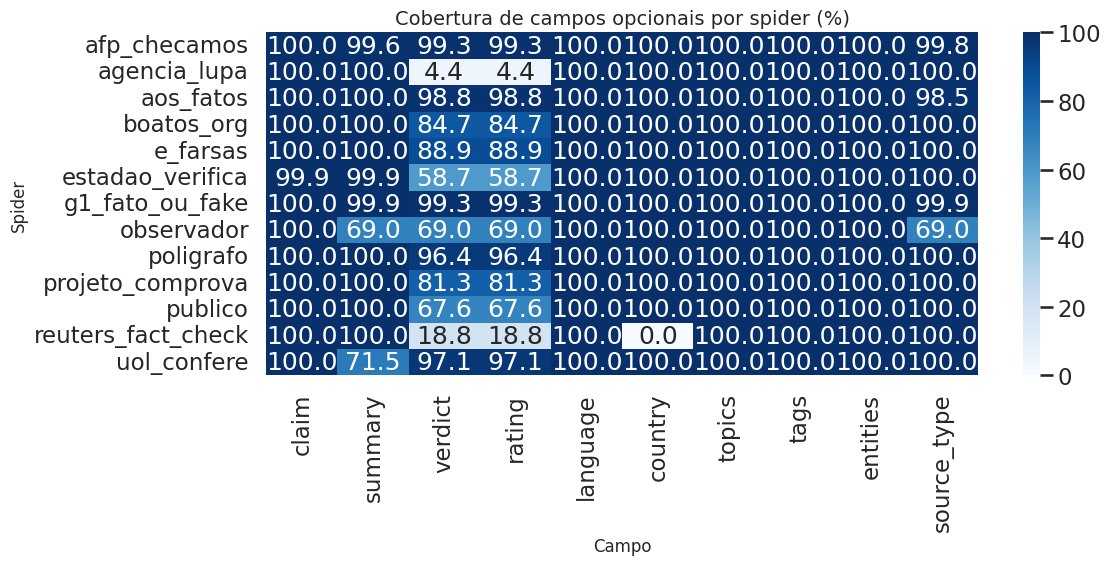

In [3]:
optional_fields = [
    "claim",
    "summary",
    "verdict",
    "rating",
    "language",
    "country",
    "topics",
    "tags",
    "entities",
    "source_type",
]

coverage = field_coverage(items_df, optional_fields, groupby="spider")
coverage = coverage.set_index("spider")

plt.figure(figsize=(12, 6))
sns.heatmap(coverage, annot=True, fmt=".1f", cmap="Blues")
plt.title("Cobertura de campos opcionais por spider (%)")
plt.xlabel("Campo")
plt.ylabel("Spider")
plt.tight_layout()

## Consistência temporal


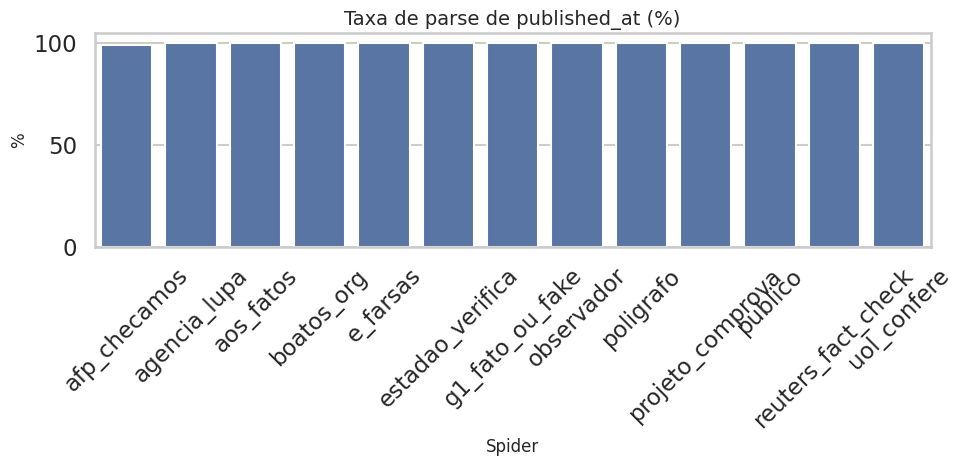

In [4]:
parse_rate = (
    items_df.groupby("spider")["published_at_dt"]
    .apply(lambda s: s.notna().mean() * 100)
    .reset_index(name="published_at_parse_pct")
)

sns.barplot(data=parse_rate, x="spider", y="published_at_parse_pct")
plt.title("Taxa de parse de published_at (%)")
plt.xlabel("Spider")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()

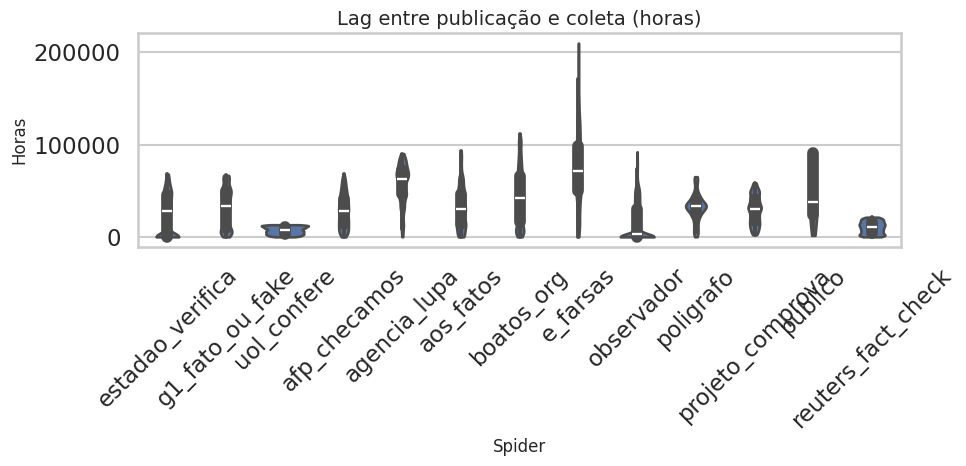

In [5]:
lag_df = items_df.dropna(subset=["lag_hours"])

sns.violinplot(data=lag_df, x="spider", y="lag_hours", cut=0)
plt.title("Lag entre publicação e coleta (horas)")
plt.xlabel("Spider")
plt.ylabel("Horas")
plt.xticks(rotation=45)
plt.tight_layout()

## Duplicidades


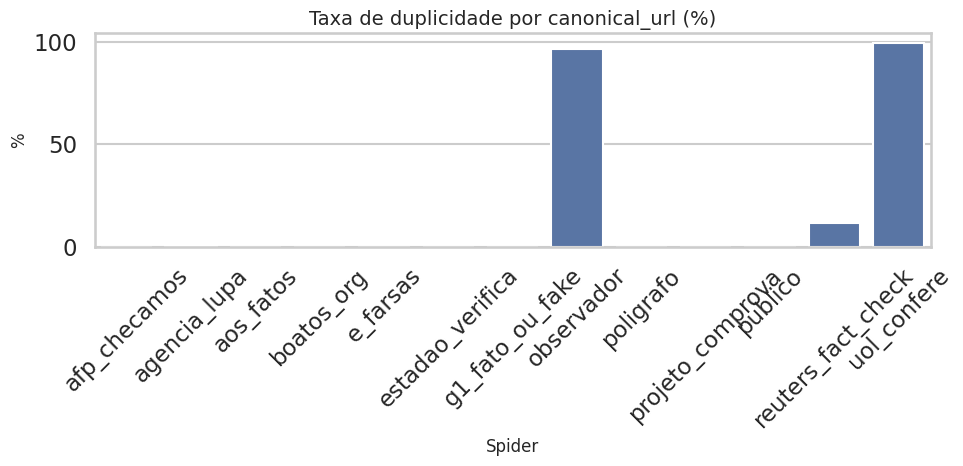

In [6]:
dup_stats = duplicate_stats(items_df, keys=["canonical_url"], groupby="spider")

sns.barplot(data=dup_stats, x="spider", y="duplicate_rate_pct")
plt.title("Taxa de duplicidade por canonical_url (%)")
plt.xlabel("Spider")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()

## Qualidade textual


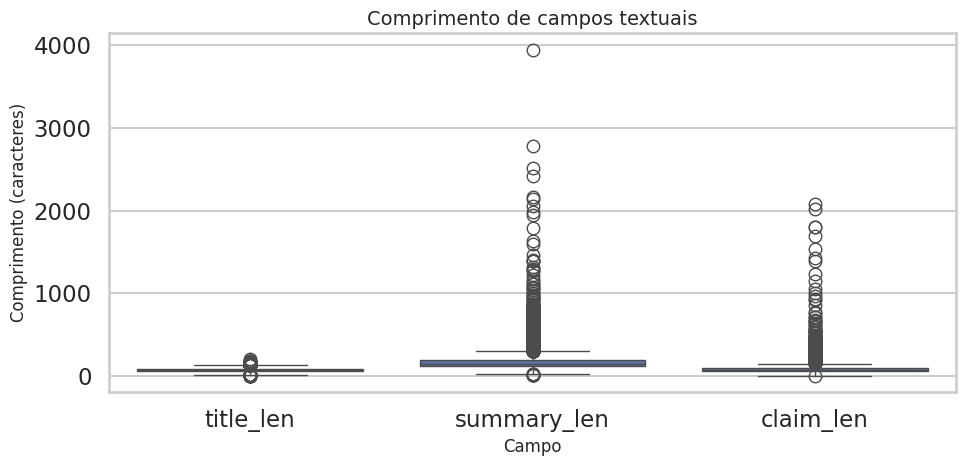

In [7]:
lengths = items_df.melt(
    value_vars=["title_len", "summary_len", "claim_len"],
    var_name="field",
    value_name="length",
)
lengths = lengths.dropna(subset=["length"])

sns.boxplot(data=lengths, x="field", y="length")
plt.title("Comprimento de campos textuais")
plt.xlabel("Campo")
plt.ylabel("Comprimento (caracteres)")
plt.tight_layout()

## Checks e alertas


In [8]:
alerts = []

for spider, group in items_df.groupby("spider"):
    total = len(group)
    invalid_publish_pct = group["published_at_dt"].isna().mean() * 100 if total else 0
    negative_lag_pct = (group["lag_hours"] < 0).mean() * 100 if total else 0

    source_eq = group["source_equals_canonical"].dropna()
    diff_url_pct = (not source_eq).mean() * 100 if len(source_eq) > 0 else 0

    coverage_row = (
        field_coverage(group, ["claim", "summary", "verdict", "rating"])
        .set_index("field")["coverage_pct"]
        .to_dict()
    )

    alerts.append(
        {
            "spider": spider,
            "published_at_invalid_pct": round(invalid_publish_pct, 2),
            "negative_lag_pct": round(negative_lag_pct, 2),
            "source_url_diff_pct": round(diff_url_pct, 2),
            "claim_coverage_pct": round(coverage_row.get("claim", 0), 2),
            "summary_coverage_pct": round(coverage_row.get("summary", 0), 2),
            "verdict_coverage_pct": round(coverage_row.get("verdict", 0), 2),
            "rating_coverage_pct": round(coverage_row.get("rating", 0), 2),
        }
    )

alerts_df = pd.DataFrame(alerts)
alerts_df

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## Achados e próximos passos
- Priorizar spiders com baixa cobertura de claim/summary/verdict/rating.
- Investigar lags negativos ou muito altos.
- Revisar canonicalização quando `source_url` diverge de `canonical_url`.
